# Dependencies

In [ ]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)
parent_dir
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [125]:
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

In [15]:
%load_ext autoreload
%autoreload 2

from src.dataset import Dataloader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fetching dataset

In [77]:
dataloader_config = {
    "time_per_datapoint_s": 1,
}
dataloader = Dataloader(dataloader_config)
dataset = dataloader.get_data()

Dataset already exists. Loading from disk.


In [78]:
dataset

,feat_avg_power,feat_narrowband_power_rate,mat_file,sampling_rate,motor_load_hp,motor_speed_rpm,fault_position,fault_type,fault_size_in,telemetry_position
0,0.008214,0.799766,/home/leomares/storage/projects/cwru-fault-det...,12000,0,1797,fan,inner,0.007,BA_0
1,0.008269,0.808135,/home/leomares/storage/projects/cwru-fault-det...,12000,0,1797,fan,inner,0.007,BA_0
2,0.008021,0.823328,/home/leomares/storage/projects/cwru-fault-det...,12000,0,1797,fan,inner,0.007,BA_0
3,0.007754,0.846633,/home/leomares/storage/projects/cwru-fault-det...,12000,0,1797,fan,inner,0.007,BA_0
4,0.007816,0.842415,/home/leomares/storage/projects/cwru-fault-det...,12000,0,1797,fan,inner,0.007,BA_0
...,...,...,...,...,...,...,...,...,...,...
41780,0.007428,0.131272,/home/leomares/storage/projects/cwru-fault-det...,12000,3,1730,NaN,NaN,NaN,FE_0
41781,0.006873,0.132987,/home/leomares/storage/projects/cwru-fault-det...,12000,3,1730,NaN,NaN,NaN,FE_0
41782,0.007488,0.128053,/home/leomares/storage/projects/cwru-fault-det...,12000,3,1730,NaN,NaN,NaN,FE_0
41783,0.006050,0.152605,/home/leomares/storage/projects/cwru-fault-det...,12000,3,1730,NaN,NaN,NaN,FE_0


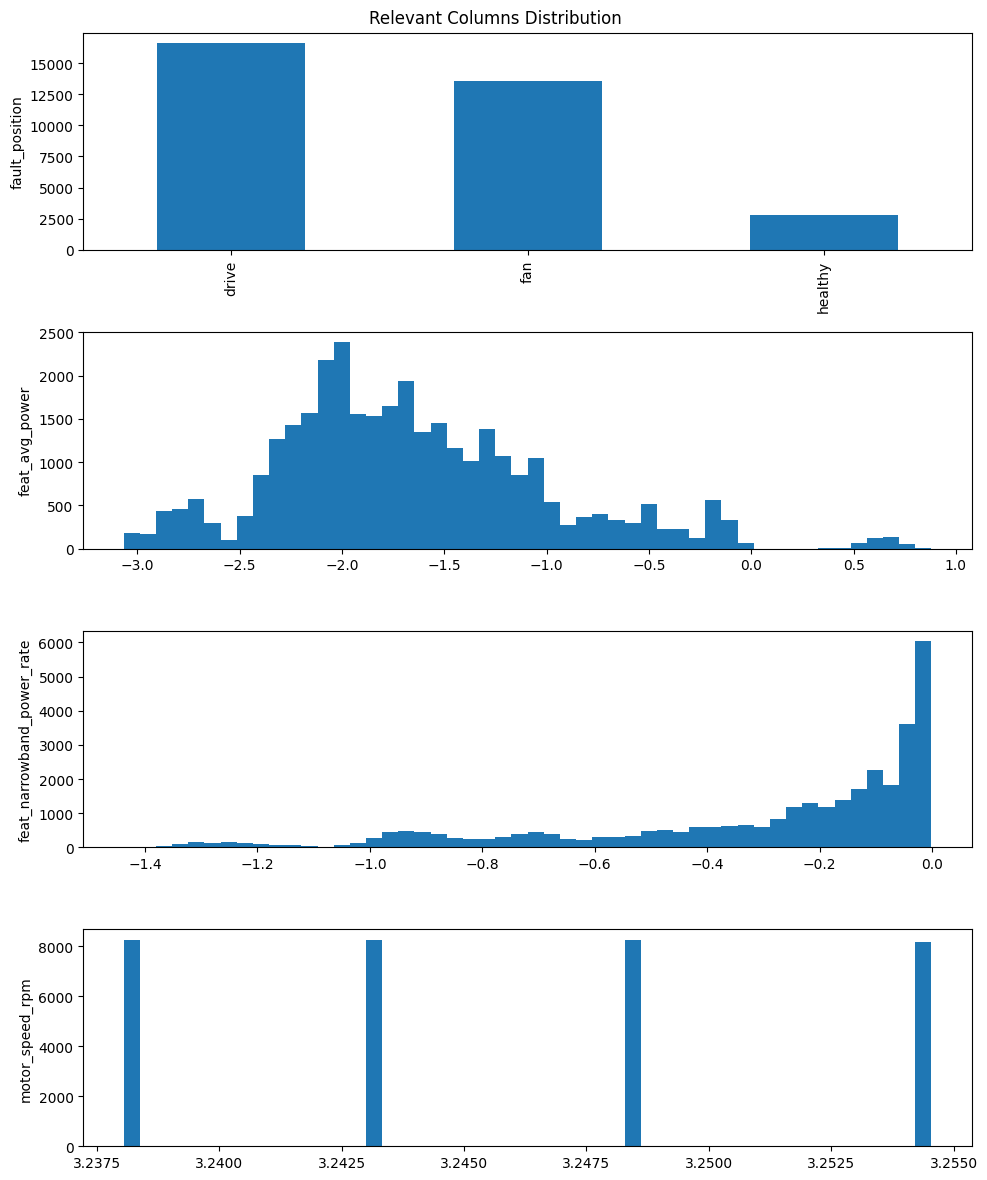

In [96]:
relevant_columns = [
    "fault_position",
    "feat_avg_power",
    "feat_narrowband_power_rate",
    "motor_speed_rpm",
]
curr_dataset = dataset.copy()
healthy_mask = curr_dataset["fault_type"].isna() | curr_dataset["fault_position"].isna()
curr_dataset.loc[healthy_mask, "fault_type"] = "healthy"
curr_dataset.loc[healthy_mask, "fault_position"] = "healthy"

# curr_dataset = curr_dataset[curr_dataset["fault_type"] == "healthy"]

fig, axs = plt.subplots(len(relevant_columns), 1, figsize=(10, 3 * len(relevant_columns)))
for i, col in enumerate(relevant_columns):
    if curr_dataset[col].dtype == "str" or curr_dataset[col].dtype == "category":
        curr_dataset[col] = curr_dataset[col].astype("category")
        curr_dataset[col].value_counts().plot(kind="bar", ax=axs[i])
    elif curr_dataset[col].dtype == "float64" or curr_dataset[col].dtype == "int64":
        curr_dataset[col].apply(np.log10).hist(bins=50, ax=axs[i])
    else:
        print(f"Column {col} has unsupported dtype {curr_dataset[col].dtype}")
        continue
    axs[i].set_ylabel(col)
    axs[i].set_xlabel("")
    axs[i].grid(False)

fig.suptitle("Relevant Columns Distribution")
fig.tight_layout()

Theres an imbalance between the classes, so we must develop some method to oversample the healthy label later on. 

Logarithms were applied to the data in order to distribute more evenly the feature values.

# Model Proposal 1

A model that detects if theres a fault at all, not discriminating type or position relative to sensor. It receives one sensor read and computes how likely that signal represents a fault

In [ ]:
curr_dataset = dataset.copy().sample(frac=1, random_state=42)
curr_dataset["has_fault"] = curr_dataset["fault_type"].notna()
curr_dataset["feat_avg_power"] = curr_dataset["feat_avg_power"].apply(np.log1p)
curr_dataset["feat_narrowband_power_rate"] = curr_dataset["feat_narrowband_power_rate"].apply(np.log1p)

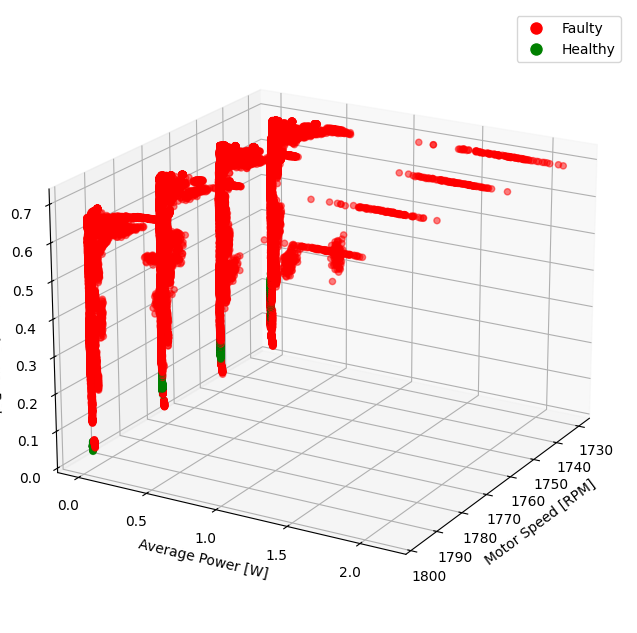

In [107]:
fig = plt.figure(figsize=(8,6),dpi=100)
ax = fig.add_subplot(projection='3d', elev=20, azim=30)

ax.scatter(
    xs=curr_dataset["motor_speed_rpm"],
    ys=curr_dataset["feat_avg_power"],
    zs=curr_dataset["feat_narrowband_power_rate"],
    c=curr_dataset["has_fault"].map({True: "red", False: "green"}),
    alpha=0.5,
)
ax.set_xlabel("Motor Speed [RPM]")
ax.set_ylabel("Average Power [W]")
ax.set_zlabel("Narrowband Power Rate")
ax.legend(handles=[
    plt.plot([],[], marker='o', color='w', label='Faulty', markerfacecolor='red', markersize=10)[0],
    plt.plot([],[], marker='o', color='w', label='Healthy', markerfacecolor='green', markersize=10)[0]
])
fig.tight_layout(pad=-0.5)

In [121]:
models = {
    "XGBClassifier": XGBClassifier(
        n_estimators=5, 
        max_depth=3, 
        learning_rate=1, 
        objective='binary:logistic',
        scale_pos_weight=curr_dataset["has_fault"].value_counts()[False] / curr_dataset["has_fault"].value_counts()[True],
    ),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
}

In [122]:
def k_fold(dataset: pd.DataFrame, k: int = 5, oversample: bool = False):
    input_columns = ["motor_speed_rpm","feat_avg_power","feat_narrowband_power_rate"]
    output_columns = ["has_fault"]
    X = dataset[input_columns].values
    y = dataset[output_columns].values

    folds = np.array_split(np.arange(len(X)), k)
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        if oversample:
            n_per_class = np.unique(y[train_idx], return_counts=True) # [[labels], [counts]]
            diffs = n_per_class[1].max() - n_per_class[1]
            for class_value, n_samples in zip(n_per_class[0], diffs):
                if n_samples > 0:
                    class_idx = train_idx[y[train_idx] == class_value]
                    oversampled_idx = np.random.choice(class_idx, size=n_samples, replace=True)
                    train_idx = np.concatenate([train_idx, oversampled_idx])

        yield X[train_idx], y[train_idx], X[test_idx], y[test_idx]

In [127]:
preds = defaultdict(list)
for model_name, model in models.items():
    for X_train, y_train, X_test, y_test in k_fold(curr_dataset, k=5):
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        y_pred = model.predict(X_test)
        classification_report_str = classification_report(y_test, y_pred, target_names=["Healthy", "Faulty"])
        preds[model_name].append(score)
    print(f"{model_name} score: [{np.min(preds[model_name])*100:.2f},{np.max(preds[model_name])*100:.2f}]")

XGBClassifier score: [98.60,98.94]
DecisionTreeClassifier score: [99.61,99.70]


# Model Proposal 2
A multi-label classifier, to separate between types. In order to do that, it may be needed to extract patterns from the time series or its fft format for each fault.

Extract the FFT -> train an auto-encoder as an embedding -> use its latent variables as input

Its still receives one sensor reading to make the inference.

# Model Proposal 3
Detect the position from different telemetry positions.